# Check parquet integrity

The following notebook explores the metadata parquet created by build_metadata_table.py. Much of the following EDA relates to confirming joining logic and ensuring results are as expected. Finally, a cleaned dataframe is created. Also note that the following performs site/field-level embeddings, not well-level embeddings.

In [1]:
import pandas as pd
import numpy as np

# Load data
PATH = "../data/processed/master_metadata.parquet"
df = pd.read_parquet(PATH)

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

Shape: (16174, 43)

Columns:
 ['url_origlowzbf', 'url_orighighzbf', 'url_origbrightfield', 'plate', 'well', 'site', 'metadata_abspositionz', 'metadata_abstime', 'metadata_binningx', 'metadata_binningy', 'metadata_channelid', 'metadata_channelname', 'metadata_col', 'metadata_exposuretime', 'metadata_fieldid', 'metadata_imageresolutionx', 'metadata_imageresolutiony', 'metadata_imagesizex', 'metadata_imagesizey', 'metadata_mainemissionwavelength', 'metadata_mainexcitationwavelength', 'metadata_maxintensity', 'metadata_objectivemagnification', 'metadata_objectivena', 'metadata_planeid', 'metadata_positionx', 'metadata_positiony', 'metadata_positionz', 'metadata_row', 'broad_sample', 'solvent', 'InChIKey', 'pert_iname', 'pubchem_cid', 'gene', 'pert_type', 'control_type', 'smiles', 'dna_img_path', 'agp_img_path', 'mito_img_path', 'er_img_path', 'rna_img_path']


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16174 entries, 0 to 16173
Data columns (total 43 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   url_origlowzbf                     16174 non-null  object 
 1   url_orighighzbf                    16174 non-null  object 
 2   url_origbrightfield                16174 non-null  object 
 3   plate                              16174 non-null  object 
 4   well                               16174 non-null  object 
 5   site                               16174 non-null  int64  
 6   metadata_abspositionz              16174 non-null  float64
 7   metadata_abstime                   16174 non-null  object 
 8   metadata_binningx                  16174 non-null  int64  
 9   metadata_binningy                  16174 non-null  int64  
 10  metadata_channelid                 16174 non-null  int64  
 11  metadata_channelname               16174 non-null  obj

In [3]:
df.head(20)

,url_origlowzbf,url_orighighzbf,url_origbrightfield,plate,well,site,metadata_abspositionz,metadata_abstime,metadata_binningx,metadata_binningy,...,pubchem_cid,gene,pert_type,control_type,smiles,dna_img_path,agp_img_path,mito_img_path,er_img_path,rna_img_path
0,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,BR00116991,A01,1,0.134679,2020-11-05T19:55:20.94-05:00,2,2,...,9883933.0,CACNB4,trt,unknown,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...
1,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,BR00116991,A01,2,0.134679,2020-11-05T19:55:22.673-05:00,2,2,...,9883933.0,CACNB4,trt,unknown,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...
2,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,BR00116991,A01,3,0.134673,2020-11-05T19:55:24.217-05:00,2,2,...,9883933.0,CACNB4,trt,unknown,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...
3,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,BR00116991,A01,4,0.134674,2020-11-05T19:55:25.747-05:00,2,2,...,9883933.0,CACNB4,trt,unknown,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...
4,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,BR00116991,A01,5,0.134681,2020-11-05T19:55:27.243-05:00,2,2,...,9883933.0,CACNB4,trt,unknown,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...
5,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,BR00116991,A01,6,0.134677,2020-11-05T19:55:28.77-05:00,2,2,...,9883933.0,CACNB4,trt,unknown,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...
6,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,BR00116991,A01,7,0.134674,2020-11-05T19:55:30.317-05:00,2,2,...,9883933.0,CACNB4,trt,unknown,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/r

In [4]:
# Check missing values
missing = df.isna().mean().sort_values(ascending=False)
print(missing.head(20))

pubchem_cid                        0.027822
pert_iname                         0.000000
metadata_planeid                   0.000000
metadata_positionx                 0.000000
metadata_positiony                 0.000000
metadata_positionz                 0.000000
metadata_row                       0.000000
broad_sample                       0.000000
solvent                            0.000000
InChIKey                           0.000000
url_origlowzbf                     0.000000
metadata_objectivemagnification    0.000000
gene                               0.000000
pert_type                          0.000000
control_type                       0.000000
smiles                             0.000000
dna_img_path                       0.000000
agp_img_path                       0.000000
mito_img_path                      0.000000
er_img_path                        0.000000
dtype: float64


Note - image missingness due to only downloading subset of rows from plate

In [5]:
# Show treatment counts
if "broad_sample" in df.columns:
    print("\nunique compounds:", df["broad_sample"].nunique())


unique compounds: 307


In [6]:
# Check unique sites per well
if "site" in df.columns:
    print(df.groupby("well")["site"].nunique().describe())

count    384.0
mean       9.0
std        0.0
min        9.0
25%        9.0
50%        9.0
75%        9.0
max        9.0
Name: site, dtype: float64


In [7]:
# Confirm no missing plates/wells
assert df["plate"].notna().all(), "Missing plate values!"
assert df["well"].notna().all(), "Missing well values!"

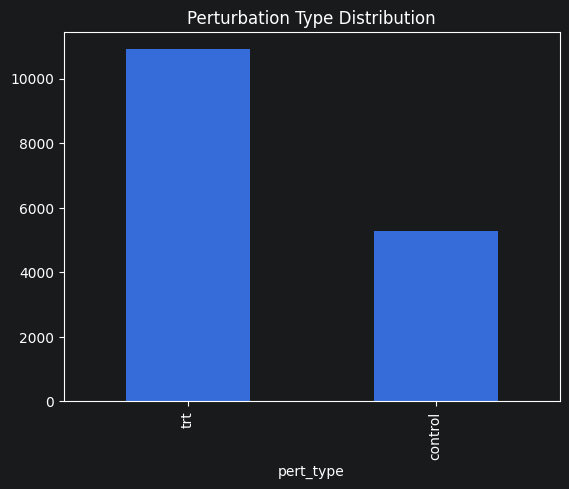

In [8]:
# Show perturbation type distribution
import matplotlib.pyplot as plt

df["pert_type"].value_counts().plot(kind="bar")
plt.title("Perturbation Type Distribution")
plt.show()

# EDA of parquet

In [9]:
# Descriptive stats
print("Unique plates:", df["plate"].nunique())
print("Unique wells:", df["well"].nunique())
print("Unique sites:", df["site"].nunique())
print("\nSites per well:")
print(df.groupby(["plate", "well"])["site"].nunique().describe())

Unique plates: 5
Unique wells: 384
Unique sites: 9

Sites per well:
count    1802.000000
mean        8.975583
std         0.376227
min         1.000000
25%         9.000000
50%         9.000000
75%         9.000000
max         9.000000
Name: site, dtype: float64


In [10]:
# Print gene counts
gene_counts = (
    df.groupby("gene")
    .size()
    .sort_values(ascending=False)
)

print(gene_counts.head(20))

print("\nUnique genes:", df["gene"].nunique())
print("Median rows per gene:", gene_counts.median())

gene
unknown    2719
HIF1A        90
MME          90
ELANE        90
EDNRB        90
DYRK1B       90
DNMT3A       90
DHH          90
MMP2         90
NTRK1        90
OPRL1        90
P3H1         90
PARP3        90
PDE7A        90
CSK          90
PLA2G1B      90
PLD1         90
EZH2         90
MET          90
FFAR4        90
dtype: int64

Unique genes: 161
Median rows per gene: 81.0


In [11]:
# Print controls
print(df["control_type"].value_counts(dropna=False))
print("\nTreatment vs controls:")
print(df["pert_type"].value_counts(dropna=False))

control_type
unknown           10899
negcon             2719
poscon_diverse     1206
poscon_cp          1089
poscon_orf          261
Name: count, dtype: int64

Treatment vs controls:
pert_type
trt        10899
control     5275
Name: count, dtype: int64


In [12]:
# Confirm consistent image sizes
cols = ["metadata_imagesizex", "metadata_imagesizey"]
for c in cols:
    if c in df.columns:
        print(c)
        print(df[c].value_counts())

metadata_imagesizex
metadata_imagesizex
1080    16174
Name: count, dtype: int64
metadata_imagesizey
metadata_imagesizey
1080    16174
Name: count, dtype: int64


In [13]:
# Show duplicate biological-image rows
dup_mask = df.duplicated(["plate", "well", "site"], keep=False)
print("Total duplicate rows:", dup_mask.sum())

if dup_mask.any():
    print("\nExample duplicates:")
    print(df[dup_mask].sort_values(["plate", "well", "site"]).head(20))

Total duplicate rows: 0


In [14]:
# Show sample image paths
sample = df.sample(5)

channel_cols = [
    "mito_img_path",
    "agp_img_path",
    "rna_img_path",
    "er_img_path",
    "dna_img_path"
]

for _, row in sample.iterrows():
    print("\nWELL:", row["well"])
    print("SITE:", row["site"])
    print("CHANNEL PATHS:")

    for c in channel_cols:
        print(f"  {c}: {row[c]}")


WELL: N10
SITE: 4
CHANNEL PATHS:
  mito_img_path: /scratch/creighton.jo/cellpainting/data/raw/images/BR00116991/r14c10f04p01-ch1sk1fk1fl1.tiff
  agp_img_path: /scratch/creighton.jo/cellpainting/data/raw/images/BR00116991/r14c10f04p01-ch2sk1fk1fl1.tiff
  rna_img_path: /scratch/creighton.jo/cellpainting/data/raw/images/BR00116991/r14c10f04p01-ch3sk1fk1fl1.tiff
  er_img_path: /scratch/creighton.jo/cellpainting/data/raw/images/BR00116991/r14c10f04p01-ch4sk1fk1fl1.tiff
  dna_img_path: /scratch/creighton.jo/cellpainting/data/raw/images/BR00116991/r14c10f04p01-ch5sk1fk1fl1.tiff

WELL: K14
SITE: 9
CHANNEL PATHS:
  mito_img_path: /scratch/creighton.jo/cellpainting/data/raw/images/BR00116991/r11c14f09p01-ch1sk1fk1fl1.tiff
  agp_img_path: /scratch/creighton.jo/cellpainting/data/raw/images/BR00116991/r11c14f09p01-ch2sk1fk1fl1.tiff
  rna_img_path: /scratch/creighton.jo/cellpainting/data/raw/images/BR00116991/r11c14f09p01-ch3sk1fk1fl1.tiff
  er_img_path: /scratch/creighton.jo/cellpainting/data/raw/

# Preprocessing

In [15]:
keep_cols = [
    "plate",
    "well",
    "site",
    "broad_sample",
    "pert_iname",
    "pert_type",
    "control_type",
    "gene",
    "smiles",
    "InChIKey",
    "mito_img_path",
    "agp_img_path",
    "rna_img_path",
    "er_img_path",
    "dna_img_path"
]

clean_df = df[keep_cols].copy()
clean_df.head(20)
clean_df = df[keep_cols].copy()
clean_df.head(20)

,plate,well,site,broad_sample,pert_iname,pert_type,control_type,gene,smiles,InChIKey,mito_img_path,agp_img_path,rna_img_path,er_img_path,dna_img_path
0,BR00116991,A01,1,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,unknown,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...
1,BR00116991,A01,2,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,unknown,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...
2,BR00116991,A01,3,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,unknown,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...
3,BR00116991,A01,4,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,unknown,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...
4,BR00116991,A01,5,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,unknown,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...
5,BR00116991,A01,6,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,unknown,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...
6,BR00116991,A01,7,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,unknown,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...
7,BR00116991,A01,8,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,unknown,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...
8,BR00116991,A01,9,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,unknown,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...
9,BR00116991,A02,1,unknown,DMSO,control,negcon,unknown,CS(=O)C,IAZDPXIOMUYVGZ-UHFFFAOYSA-N,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,/scratch/creighton.jo/cellpainting/data/raw/im...,

In [16]:
print(clean_df["plate"].value_counts())

plate
BR00116991    3456
BR00116995    3456
BR00116994    3447
BR00116993    3419
BR00116992    2396
Name: count, dtype: int64


In [17]:
compound_counts = df["broad_sample"].value_counts()

print("Top 1% compounds fraction:",
      compound_counts.head(int(len(compound_counts)*0.01)).sum() /
      compound_counts.sum())

Top 1% compounds fraction: 0.17923828366514158


In [18]:
# Plate balance
print("\nPlate distribution:")
print(df["plate"].value_counts(normalize=True))

# Compound skew
compound_counts = df["broad_sample"].value_counts()

print("\nTop 10 compounds:")
print(compound_counts.head(10))

print("\nTop 1% dominance ratio:")
top_1pct = compound_counts.head(int(len(compound_counts) * 0.01)).sum()
print(top_1pct / compound_counts.sum())


Plate distribution:
plate
BR00116991    0.213676
BR00116995    0.213676
BR00116994    0.213120
BR00116993    0.211389
BR00116992    0.148139
Name: proportion, dtype: float64

Top 10 compounds:
broad_sample
unknown                   2719
BRD-K03406345-001-21-1      90
BRD-K64800655-001-09-0      90
BRD-K41599323-001-02-3      90
BRD-K23363278-001-02-1      90
BRD-K86525559-001-07-8      90
BRD-K25412176-001-01-9      90
BRD-K64890080-001-02-1      90
BRD-K33882852-003-02-8      90
BRD-K42191735-001-08-7      81
Name: count, dtype: int64

Top 1% dominance ratio:
0.17923828366514158
